# v2 Dataset Report — Sinhala-English Code-Mixed Sentiment Analysis

Thesis-report generator for the v2 dataset (10,160 rows). Run **top to bottom, in order**
(later cells reuse variables from earlier ones). Every stage prints descriptive statistics
and immediately saves a publication-quality pastel figure (dpi=300) into `../results/figures/`,
tables into `../results/tables/`, and a summary report into `../results/reports/`.

**Prerequisite:** the preprocessing pipeline has been run from `ml/`:
`validate_schema → quarantine → clean_text → language_id → make_splits → tokenize_cache`
so that `../data/interim/lid.csv` and `../data/processed/splits/` exist.

In [1]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\Ruwini Tharanga\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [2]:
# Cell 1 — setup: paths, pastel theme, helper functions
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

ROOT = Path("..").resolve()            # ml/
FIG_DIR = ROOT / "results" / "figures"
TAB_DIR = ROOT / "results" / "tables"
REP_DIR = ROOT / "results" / "reports"
for d in (FIG_DIR, TAB_DIR, REP_DIR):
    d.mkdir(parents=True, exist_ok=True)

# --- pastel thesis theme -------------------------------------------------
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300,
    "axes.titlesize": 15, "axes.labelsize": 13,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 11,
})
SENT_COLORS = {"positive": "#A8D5BA", "negative": "#F4A6A6", "neutral": "#A6C8E8"}
SENT_ORDER = ["positive", "negative", "neutral"]

# Sinhala-capable font for tick labels / wordclouds (Windows: Iskoola Pota)
SINHALA_TTF = Path(r"C:\Windows\Fonts\iskpota.ttf")
if SINHALA_TTF.exists():
    fm.fontManager.addfont(str(SINHALA_TTF))
    plt.rcParams["font.family"] = ["Iskoola Pota", "DejaVu Sans"]

def save_fig(fig, filename, purpose, observations):
    """Save at thesis quality and print the required provenance block."""
    path = FIG_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Figure saved : {path}")
    print(f"Purpose      : {purpose}")
    print(f"Observations : {observations}")

def stage_stats(df, stage):
    """Descriptive statistics printed after every processing stage."""
    print(f"===== {stage} =====")
    print(f"shape: {df.shape}")
    print("\ncolumns / dtypes:")
    print(df.dtypes.to_string())
    print("\nmissing values per column:")
    print(df.isna().sum().to_string())
    if "sentiment_label" in df.columns:
        print("\nsentiment_label distribution:")
        print(df["sentiment_label"].value_counts().to_string())
    if "language_type" in df.columns:
        print("\nlanguage_type distribution:")
        print(df["language_type"].value_counts().to_string())
    num = df.select_dtypes("number")
    if len(num.columns):
        print("\nnumeric summary:")
        print(num.describe().to_string())

def save_table(df, name):
    path = TAB_DIR / name
    df.to_csv(path, encoding="utf-8")
    print(f"Table saved  : {path}")

print("Setup complete. Figures ->", FIG_DIR)

Setup complete. Figures -> C:\Users\Ruwini Tharanga\Videos\2026\Sinhala_English_Code_Mixed_Sentiment_Analysis\ml\results\figures


In [3]:
# Cell 2 — Stage 1: raw dataset loading + statistics
raw = pd.read_csv(ROOT / "data" / "raw" / "singlish_mixed_sentiment_complete.csv",
                  encoding="utf-8-sig")
stage_stats(raw, "Stage 1: raw dataset")
save_table(raw["sentiment_label"].value_counts().rename("count").to_frame(),
           "tab_01_raw_sentiment_distribution.csv")
save_table(raw["source_platform"].value_counts().rename("count").to_frame(),
           "tab_02_raw_platform_distribution.csv")

===== Stage 1: raw dataset =====
shape: (10160, 11)

columns / dtypes:
id                  int64
text               object
sentiment_label    object
source_platform    object
source_url         object
language_type      object
clean_text         object
text_length         int64
domain             object
content_type       object
emotion            object

missing values per column:
id                 0
text               0
sentiment_label    0
source_platform    0
source_url         6
language_type      0
clean_text         0
text_length        0
domain             0
content_type       0
emotion            0

sentiment_label distribution:
sentiment_label
positive    3564
negative    3495
neutral     3101

language_type distribution:
language_type
singlish      6071
code-mixed    1896
sinhala       1266
english        908
other           11
unknown          8

numeric summary:
                 id   text_length
count  10160.000000  10160.000000
mean    5080.500000     62.043799
std     2

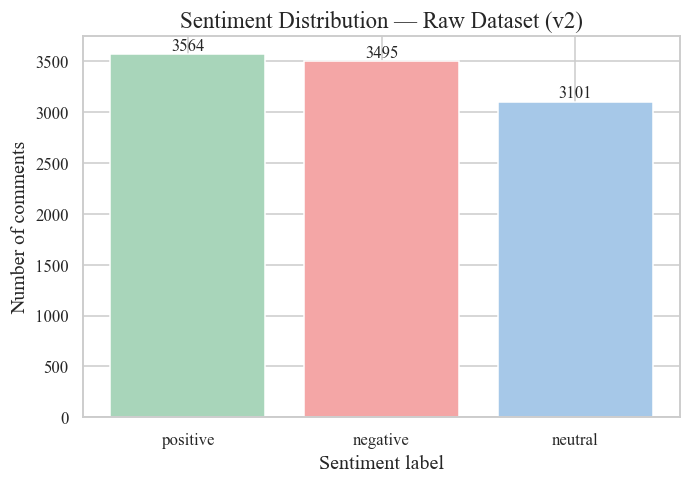

Figure saved : C:\Users\Ruwini Tharanga\Videos\2026\Sinhala_English_Code_Mixed_Sentiment_Analysis\ml\results\figures\fig_01_raw_dataset_distribution.png
Purpose      : Class balance of the raw v2 dataset before any cleaning.
Observations : 10160 rows; positive 3564, negative 3495, neutral 3101 — near-balanced, neutral slightly smaller.


In [4]:
# Cell 3 — fig_01: raw sentiment distribution
fig, ax = plt.subplots(figsize=(7, 4.5))
counts = raw["sentiment_label"].value_counts().reindex(SENT_ORDER)
bars = ax.bar(counts.index, counts.values,
              color=[SENT_COLORS[s] for s in counts.index], edgecolor="white")
ax.bar_label(bars, fontsize=11)
ax.set_title("Sentiment Distribution — Raw Dataset (v2)")
ax.set_xlabel("Sentiment label"); ax.set_ylabel("Number of comments")
save_fig(fig, "fig_01_raw_dataset_distribution.png",
         "Class balance of the raw v2 dataset before any cleaning.",
         f"{len(raw)} rows; positive {counts['positive']}, negative {counts['negative']}, "
         f"neutral {counts['neutral']} — near-balanced, neutral slightly smaller.")

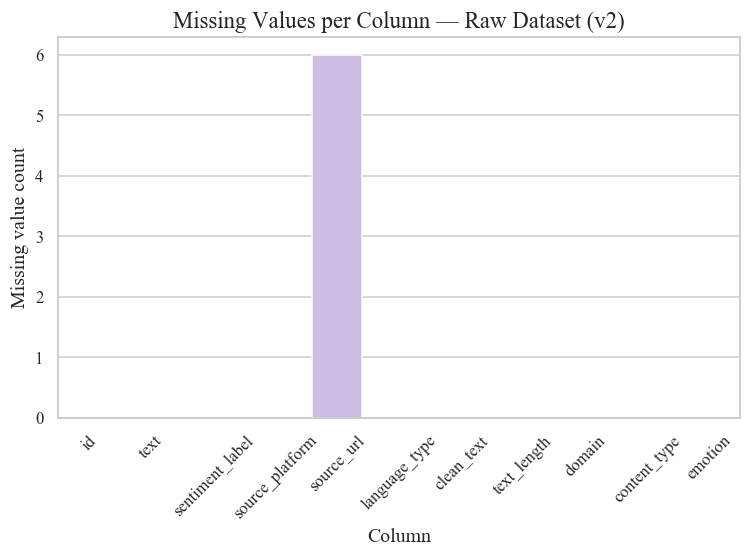

Figure saved : C:\Users\Ruwini Tharanga\Videos\2026\Sinhala_English_Code_Mixed_Sentiment_Analysis\ml\results\figures\fig_02_missing_values.png
Purpose      : Verify data completeness of the raw export.
Observations : Total missing cells: 6 — the v2 export has no missing text or labels; every row is 3-class-ready.
Table saved  : C:\Users\Ruwini Tharanga\Videos\2026\Sinhala_English_Code_Mixed_Sentiment_Analysis\ml\results\tables\tab_03_missing_values.csv


In [5]:
# Cell 4 — fig_02: missing values per column
fig, ax = plt.subplots(figsize=(8, 4.5))
miss = raw.isna().sum()
sns.barplot(x=miss.index, y=miss.values, ax=ax, color="#C9B8E8", edgecolor="white")
ax.set_title("Missing Values per Column — Raw Dataset (v2)")
ax.set_xlabel("Column"); ax.set_ylabel("Missing value count")
ax.tick_params(axis="x", rotation=45)
save_fig(fig, "fig_02_missing_values.png",
         "Verify data completeness of the raw export.",
         f"Total missing cells: {int(miss.sum())} — the v2 export has no missing "
         "text or labels; every row is 3-class-ready.")
save_table(miss.rename("missing").to_frame(), "tab_03_missing_values.csv")

===== Stages 2-4: after quarantine, text cleaning and language ID =====
shape: (10160, 14)

columns / dtypes:
id                        int64
text                     object
sentiment_label          object
source_platform          object
source_url               object
language_type            object
clean_text               object
text_length               int64
domain                   object
content_type             object
emotion                  object
language_type_manual     object
cmi                     float64
label_source             object

missing values per column:
id                      0
text                    0
sentiment_label         0
source_platform         0
source_url              6
language_type           0
clean_text              0
text_length             0
domain                  0
content_type            0
emotion                 0
language_type_manual    0
cmi                     0
label_source            0

sentiment_label distribution:
sentiment_label
pos

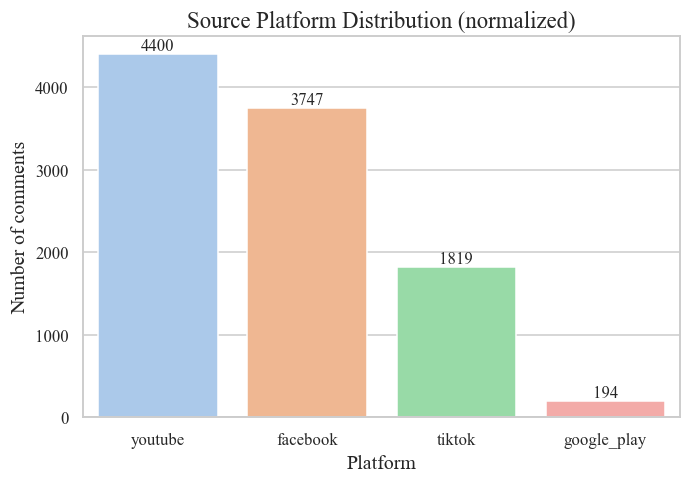

Figure saved : C:\Users\Ruwini Tharanga\Videos\2026\Sinhala_English_Code_Mixed_Sentiment_Analysis\ml\results\figures\fig_03_platform_distribution.png
Purpose      : Where the comments were collected from, after platform-name normalization.
Observations : YouTube and Facebook dominate; TikTok third; Google Play is a small slice.
Table saved  : C:\Users\Ruwini Tharanga\Videos\2026\Sinhala_English_Code_Mixed_Sentiment_Analysis\ml\results\tables\tab_04_platform_distribution.csv


In [6]:
# Cell 5 — Stage 2-4 artifacts: pipeline output (quarantine + cleaning + LID)
lid = pd.read_csv(ROOT / "data" / "interim" / "lid.csv", encoding="utf-8")
stage_stats(lid, "Stages 2-4: after quarantine, text cleaning and language ID")

# fig_03: normalized platform distribution
fig, ax = plt.subplots(figsize=(7, 4.5))
plat = lid["source_platform"].value_counts()
sns.barplot(x=plat.index, y=plat.values, ax=ax,
            palette="pastel", hue=plat.index, legend=False, edgecolor="white")
ax.set_title("Source Platform Distribution (normalized)")
ax.set_xlabel("Platform"); ax.set_ylabel("Number of comments")
for i, v in enumerate(plat.values):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=11)
save_fig(fig, "fig_03_platform_distribution.png",
         "Where the comments were collected from, after platform-name normalization.",
         "YouTube and Facebook dominate; TikTok third; Google Play is a small slice.")
save_table(plat.rename("count").to_frame(), "tab_04_platform_distribution.csv")

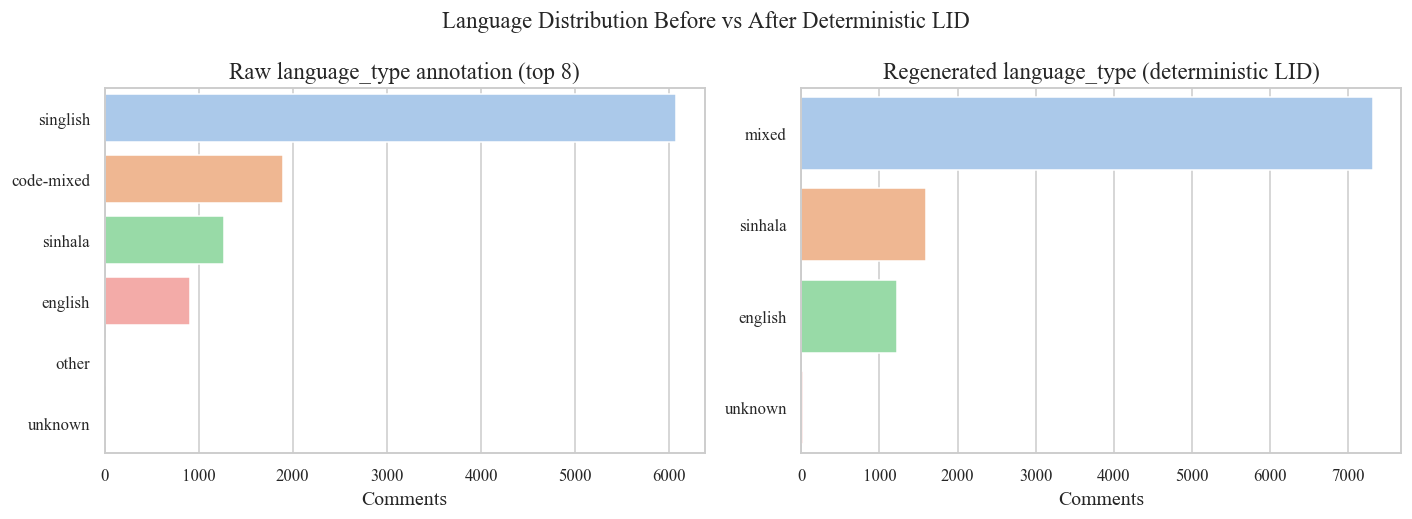

Figure saved : C:\Users\Ruwini Tharanga\Videos\2026\Sinhala_English_Code_Mixed_Sentiment_Analysis\ml\results\figures\fig_04_language_distribution.png
Purpose      : Compare inconsistent raw language annotations with the pipeline's deterministic LID.
Observations : Raw annotation had 6 inconsistent spellings; the deterministic LID collapses them to 4 canonical classes: mixed 7318, english 1223, sinhala 1600, unknown 19.
Table saved  : C:\Users\Ruwini Tharanga\Videos\2026\Sinhala_English_Code_Mixed_Sentiment_Analysis\ml\results\tables\tab_05_language_distribution.csv


In [7]:
# Cell 6 — fig_04: language distribution, raw annotation vs deterministic LID
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
raw_lang = raw["language_type"].str.strip().str.lower().value_counts().head(8)
sns.barplot(y=raw_lang.index, x=raw_lang.values, ax=axes[0],
            palette="pastel", hue=raw_lang.index, legend=False, edgecolor="white")
axes[0].set_title("Raw language_type annotation (top 8)")
axes[0].set_xlabel("Comments"); axes[0].set_ylabel("")
new_lang = lid["language_type"].value_counts()
sns.barplot(y=new_lang.index, x=new_lang.values, ax=axes[1],
            palette="pastel", hue=new_lang.index, legend=False, edgecolor="white")
axes[1].set_title("Regenerated language_type (deterministic LID)")
axes[1].set_xlabel("Comments"); axes[1].set_ylabel("")
fig.suptitle("Language Distribution Before vs After Deterministic LID", fontsize=15)
fig.tight_layout()
save_fig(fig, "fig_04_language_distribution.png",
         "Compare inconsistent raw language annotations with the pipeline's deterministic LID.",
         f"Raw annotation had {raw['language_type'].nunique()} inconsistent spellings; the "
         f"deterministic LID collapses them to 4 canonical classes: mixed {new_lang.get('mixed',0)}, "
         f"english {new_lang.get('english',0)}, sinhala {new_lang.get('sinhala',0)}, "
         f"unknown {new_lang.get('unknown',0)}.")
save_table(new_lang.rename("count").to_frame(), "tab_05_language_distribution.csv")

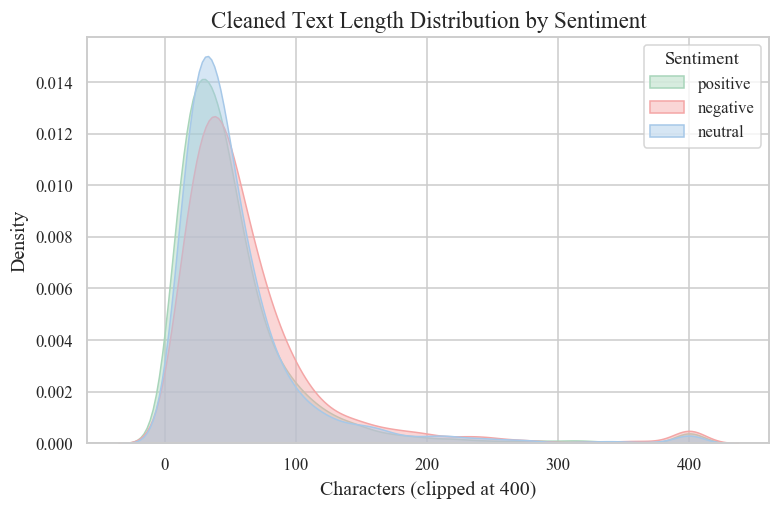

Figure saved : C:\Users\Ruwini Tharanga\Videos\2026\Sinhala_English_Code_Mixed_Sentiment_Analysis\ml\results\figures\fig_05_text_length_distribution.png
Purpose      : Check whether comment length differs across sentiment classes.
Observations : Mean length 62 chars, max 1775; all three classes are short-comment dominated with similar shapes.
Table saved  : C:\Users\Ruwini Tharanga\Videos\2026\Sinhala_English_Code_Mixed_Sentiment_Analysis\ml\results\tables\tab_06_text_length_by_sentiment.csv


In [8]:
# Cell 7 — fig_05: text length distribution by sentiment (regenerated clean_text)
lid["clean_len"] = lid["clean_text"].astype(str).str.len()
fig, ax = plt.subplots(figsize=(8, 4.8))
for s in SENT_ORDER:
    sns.kdeplot(lid.loc[lid.sentiment_label == s, "clean_len"].clip(upper=400),
                ax=ax, label=s, fill=True, alpha=0.45, color=SENT_COLORS[s])
ax.set_title("Cleaned Text Length Distribution by Sentiment")
ax.set_xlabel("Characters (clipped at 400)"); ax.set_ylabel("Density")
ax.legend(title="Sentiment")
save_fig(fig, "fig_05_text_length_distribution.png",
         "Check whether comment length differs across sentiment classes.",
         f"Mean length {lid['clean_len'].mean():.0f} chars, max {lid['clean_len'].max()}; "
         "all three classes are short-comment dominated with similar shapes.")
save_table(lid.groupby("sentiment_label")["clean_len"].describe(),
           "tab_06_text_length_by_sentiment.csv")

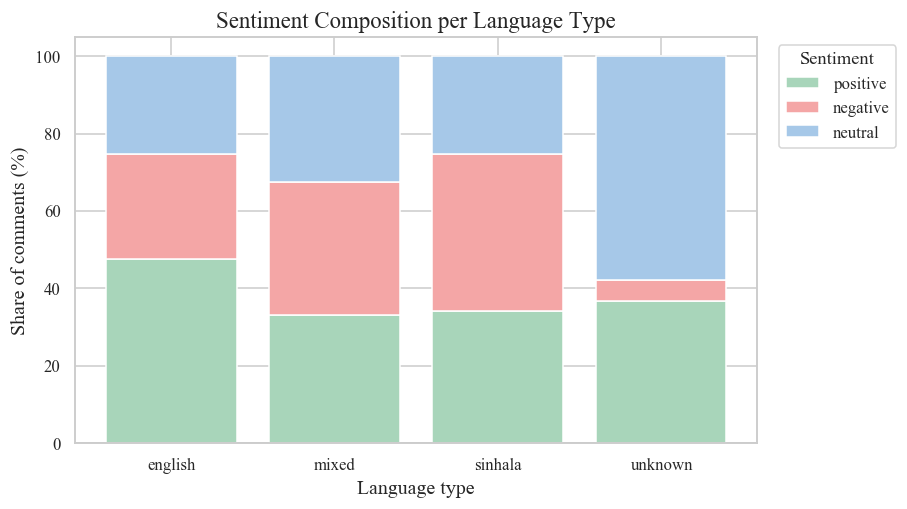

Figure saved : C:\Users\Ruwini Tharanga\Videos\2026\Sinhala_English_Code_Mixed_Sentiment_Analysis\ml\results\figures\fig_06_sentiment_by_language.png
Purpose      : Test whether sentiment balance is stable across monolingual and code-mixed text.
Observations : Class shares stay roughly balanced within each language type, so language type is not a trivial proxy for sentiment.
Table saved  : C:\Users\Ruwini Tharanga\Videos\2026\Sinhala_English_Code_Mixed_Sentiment_Analysis\ml\results\tables\tab_07_sentiment_by_language_pct.csv


In [9]:
# Cell 8 — fig_06: sentiment composition within each language type
ct = pd.crosstab(lid["language_type"], lid["sentiment_label"],
                 normalize="index").loc[:, SENT_ORDER] * 100
fig, ax = plt.subplots(figsize=(8, 4.8))
bottom = np.zeros(len(ct))
for s in SENT_ORDER:
    ax.bar(ct.index, ct[s], bottom=bottom, label=s,
           color=SENT_COLORS[s], edgecolor="white")
    bottom += ct[s].values
ax.set_title("Sentiment Composition per Language Type")
ax.set_xlabel("Language type"); ax.set_ylabel("Share of comments (%)")
ax.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
save_fig(fig, "fig_06_sentiment_by_language.png",
         "Test whether sentiment balance is stable across monolingual and code-mixed text.",
         "Class shares stay roughly balanced within each language type, so language type "
         "is not a trivial proxy for sentiment.")
save_table(ct.round(1), "tab_07_sentiment_by_language_pct.csv")

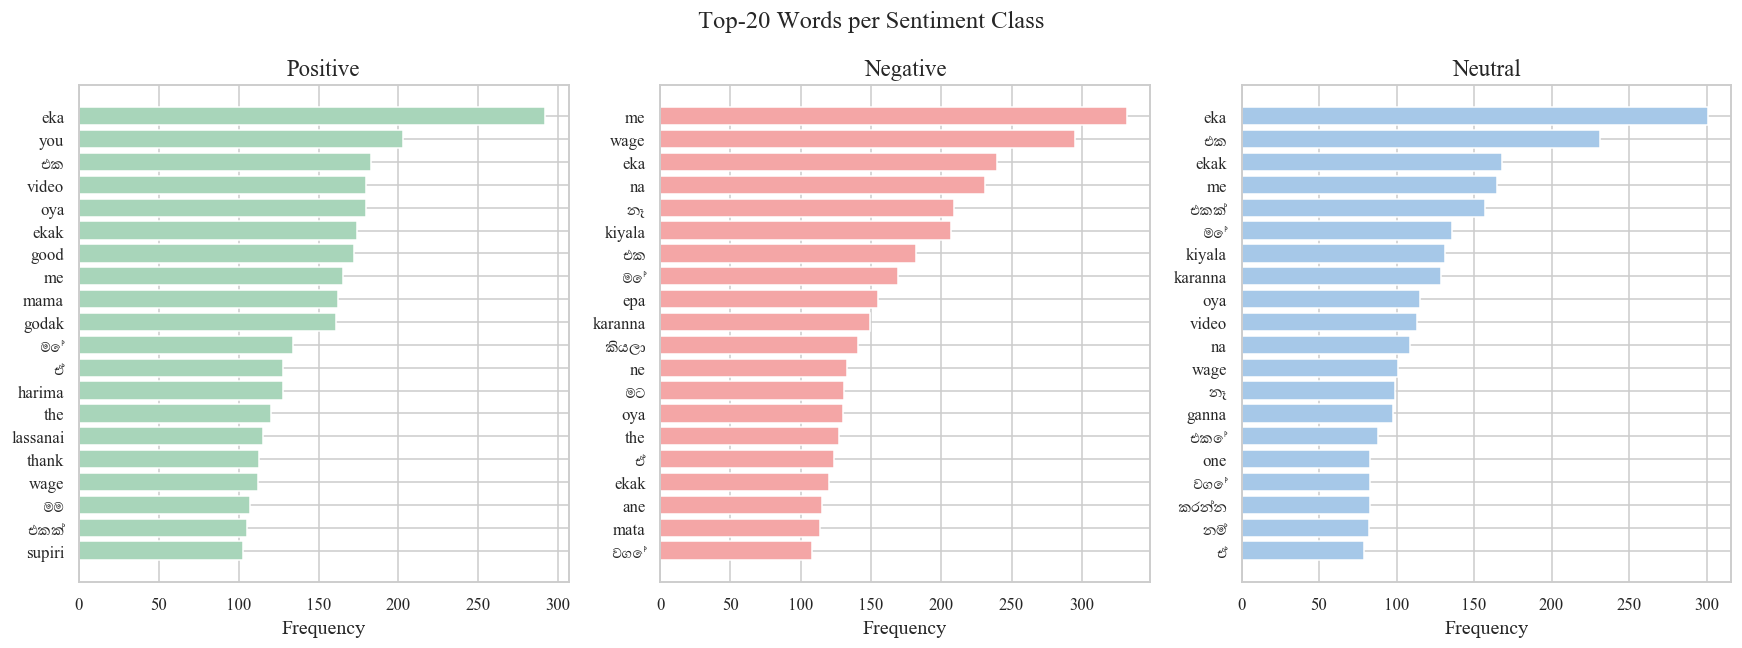

Figure saved : C:\Users\Ruwini Tharanga\Videos\2026\Sinhala_English_Code_Mixed_Sentiment_Analysis\ml\results\figures\fig_07_word_frequency.png
Purpose      : Most frequent surface tokens per class (before any stopword filtering).
Observations : High-frequency tokens are shared function words plus class-tinted words (appreciation terms in positive, complaint terms in negative).


In [10]:
# Cell 9 — fig_07: top-20 word frequencies per sentiment
def top_words(series, n=20):
    tokens = re.findall(r"[\w඀-෿']+",
                        " ".join(series.astype(str)).lower())
    return pd.Series(tokens).value_counts().head(n)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, s in zip(axes, SENT_ORDER):
    tw = top_words(lid.loc[lid.sentiment_label == s, "clean_text"])
    ax.barh(tw.index[::-1], tw.values[::-1], color=SENT_COLORS[s], edgecolor="white")
    ax.set_title(f"{s.capitalize()}")
    ax.set_xlabel("Frequency")
fig.suptitle("Top-20 Words per Sentiment Class", fontsize=16)
fig.tight_layout()
save_fig(fig, "fig_07_word_frequency.png",
         "Most frequent surface tokens per class (before any stopword filtering).",
         "High-frequency tokens are shared function words plus class-tinted words "
         "(appreciation terms in positive, complaint terms in negative).")

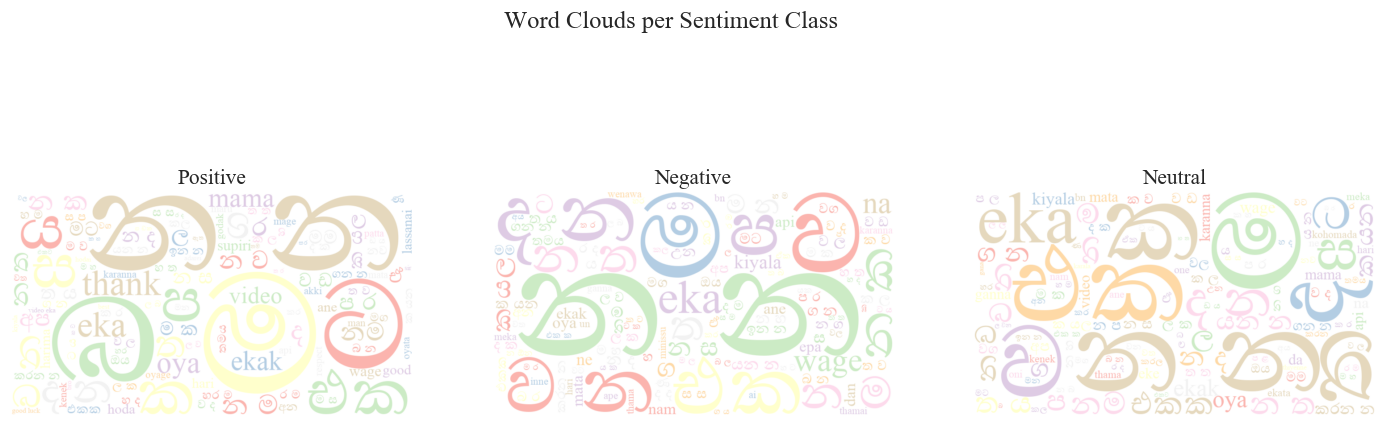

Figure saved : C:\Users\Ruwini Tharanga\Videos\2026\Sinhala_English_Code_Mixed_Sentiment_Analysis\ml\results\figures\fig_08_wordclouds.png
Purpose      : Qualitative view of dominant vocabulary per class.
Observations : Positive is dominated by appreciation/gratitude vocabulary, negative by complaint terms; Sinhala script renders via the Iskoola Pota font.


In [11]:
# Cell 10 — fig_08: word clouds per sentiment
try:
    from wordcloud import WordCloud
    font = str(SINHALA_TTF) if SINHALA_TTF.exists() else None
    fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
    for ax, s in zip(axes, SENT_ORDER):
        text = " ".join(lid.loc[lid.sentiment_label == s, "clean_text"].astype(str))
        wc = WordCloud(width=900, height=500, background_color="white",
                       font_path=font, colormap="Pastel1", max_words=120).generate(text)
        ax.imshow(wc, interpolation="bilinear"); ax.axis("off")
        ax.set_title(s.capitalize(), fontsize=14)
    fig.suptitle("Word Clouds per Sentiment Class", fontsize=16)
    save_fig(fig, "fig_08_wordclouds.png",
             "Qualitative view of dominant vocabulary per class.",
             "Positive is dominated by appreciation/gratitude vocabulary, negative by "
             "complaint terms; Sinhala script renders via the Iskoola Pota font.")
except Exception as e:
    print("Word cloud skipped:", e)

split sizes:
split
train         7096
test          1525
val           1524
unassigned      15
===== Stage 5: train split =====
shape: (7096, 16)

columns / dtypes:
id                        int64
text                     object
sentiment_label          object
source_platform          object
source_url               object
language_type            object
clean_text               object
text_length               int64
domain                   object
content_type             object
emotion                  object
language_type_manual     object
cmi                     float64
label_source             object
clean_len                 int64
split                    object

missing values per column:
id                      0
text                    0
sentiment_label         0
source_platform         0
source_url              3
language_type           0
clean_text              0
text_length             0
domain                  0
content_type            0
emotion                 0
language_

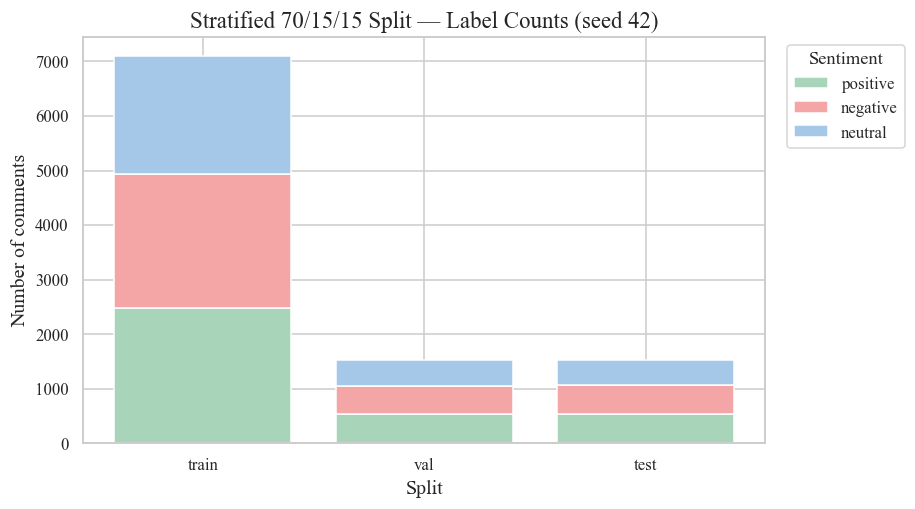

Figure saved : C:\Users\Ruwini Tharanga\Videos\2026\Sinhala_English_Code_Mixed_Sentiment_Analysis\ml\results\figures\fig_09_split_distribution.png
Purpose      : Show that stratification preserved class balance in every split.
Observations : train 7096, val 1524, test 1525; label shares identical across splits (35/34/31%).
Table saved  : C:\Users\Ruwini Tharanga\Videos\2026\Sinhala_English_Code_Mixed_Sentiment_Analysis\ml\results\tables\tab_08_split_label_counts.csv


In [12]:
# Cell 11 — Stage 5: train/val/test split statistics + fig_09
splits_dir = ROOT / "data" / "processed" / "splits"
split_ids = {name: set(pd.read_csv(splits_dir / f"{name}_ids.txt", header=None)[0])
             for name in ("train", "val", "test")}
lid["split"] = "unassigned"
for name, ids in split_ids.items():
    lid.loc[lid["id"].isin(ids), "split"] = name
print("split sizes:"); print(lid["split"].value_counts().to_string())

ct = pd.crosstab(lid["split"], lid["sentiment_label"]).loc[["train", "val", "test"], SENT_ORDER]
stage_stats(lid[lid.split == "train"], "Stage 5: train split")

fig, ax = plt.subplots(figsize=(8, 4.8))
bottom = np.zeros(3)
for s in SENT_ORDER:
    bars = ax.bar(ct.index, ct[s], bottom=bottom, label=s,
                  color=SENT_COLORS[s], edgecolor="white")
    bottom += ct[s].values
ax.set_title("Stratified 70/15/15 Split — Label Counts (seed 42)")
ax.set_xlabel("Split"); ax.set_ylabel("Number of comments")
ax.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
save_fig(fig, "fig_09_split_distribution.png",
         "Show that stratification preserved class balance in every split.",
         f"train {ct.sum(axis=1)['train']}, val {ct.sum(axis=1)['val']}, "
         f"test {ct.sum(axis=1)['test']}; label shares identical across splits (35/34/31%).")
save_table(ct, "tab_08_split_label_counts.csv")

In [13]:
# Cell 12 — summary report saved to results/reports/
lines = [
    "v2 DATASET REPORT SUMMARY",
    "=" * 40,
    f"raw rows              : {len(raw)}",
    f"3-class-ready rows    : {len(lid)}",
    f"label counts          : {raw['sentiment_label'].value_counts().to_dict()}",
    f"platforms (normalized): {lid['source_platform'].value_counts().to_dict()}",
    f"language types (LID)  : {lid['language_type'].value_counts().to_dict()}",
    f"mean clean length     : {lid['clean_len'].mean():.1f} chars",
    f"splits (seed 42)      : " + str(lid['split'].value_counts().to_dict()),
    "",
    "Figures: fig_01..fig_09 in results/figures/ (dpi=300, pastel, thesis quality)",
    "Tables : tab_01..tab_08 in results/tables/",
]
report = "\n".join(lines)
(REP_DIR / "v2_dataset_report.txt").write_text(report, encoding="utf-8")
print(report)
print("\nReport saved:", REP_DIR / "v2_dataset_report.txt")

v2 DATASET REPORT SUMMARY
raw rows              : 10160
3-class-ready rows    : 10160
label counts          : {'positive': 3564, 'negative': 3495, 'neutral': 3101}
platforms (normalized): {'youtube': 4400, 'facebook': 3747, 'tiktok': 1819, 'google_play': 194}
language types (LID)  : {'mixed': 7318, 'sinhala': 1600, 'english': 1223, 'unknown': 19}
mean clean length     : 62.0 chars
splits (seed 42)      : {'train': 7096, 'test': 1525, 'val': 1524, 'unassigned': 15}

Figures: fig_01..fig_09 in results/figures/ (dpi=300, pastel, thesis quality)
Tables : tab_01..tab_08 in results/tables/

Report saved: C:\Users\Ruwini Tharanga\Videos\2026\Sinhala_English_Code_Mixed_Sentiment_Analysis\ml\results\reports\v2_dataset_report.txt
